In [1]:
# Load necessary libraries
library(dplyr)
library(tidyr)
library(ggplot2)
library(data.table)
library(fixest)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last




In [2]:
# Custom colors from the provided image 
flexible_color <- "#4C515C"  # Replace with the exact hex code for Flexible
cosy_color <- "#5F8ED9"      # Replace with the exact hex code for Cosy
hp_color <- "#AD87CA"
not_hp_color <- "#2D354A"


In [3]:
# Read the CSV file for EV charging events
ev_charging <- fread("../data/input/cosy_-_ev_detection_2024_07_04.csv") %>%
  mutate(ev_charging = 1)

head(ev_charging)

account_id,hashed_mpan,interval_start,read_value,ev_charging
<int>,<int>,<dttm>,<dbl>,<dbl>
6787,936933584,2023-06-15 00:00:00,3.755,1
6787,936933584,2023-06-15 00:30:00,3.779,1
6787,936933584,2023-06-15 01:00:00,3.790,1
6787,936933584,2023-06-15 01:30:00,3.764,1
6787,936933584,2023-06-15 02:00:00,3.811,1
6787,936933584,2023-06-15 02:30:00,3.760,1


In [6]:


# Read the files (HP Installation, Cosy Adoption and Daily Weather)
hp <- fread("../data/input/cosy_-_half_hourly_data_for_hp_sample_2024_09_26.csv") %>%
    rename(interval_start = adjusted_interval_start)

# weather data
weather <- fread("../data/input/Cosy Analysis Weather Mar 26 daily.csv") %>% 
  rename_with(.cols = starts_with("weekly"), 
              .fn = ~ sub("^weekly", "daily", .)) %>%
  rename(tariff_gsp_group_id=gsp_group_id) %>%
  mutate(date=as.Date(date_day, format = "%Y-%m-%d"))

# Select some random mpans
# set.seed(12345)
# sample_selection <- sample(unique(hp$account_id), 350)
  
# Create Treatment dummy and Settlement Categorical
hp <- hp %>%
  #filter(account_id %in% sample_selection) %>%
  inner_join(fread("../data/input/cosy_-_hp_details_2024_06_25.csv") %>% distinct(hashed_mpan, .keep_all=TRUE), by=c("hashed_mpan")) %>%
  mutate(settlement_date = as.Date(interval_start),
         installed_at = as.Date(installed_at),
         settlement_time = format(as.POSIXct(interval_start),
                            format="%H:%M"), #format time
        is_hp_installed = as.numeric(installed_at <= settlement_date)
                            ) %>%
  left_join(weather, by = c("settlement_date" = "date", "tariff_gsp_group_id")) %>%
  arrange(interval_start) %>%
  group_by(settlement_time) %>%
  mutate(settlement_period = cur_group_id())   # Read the CSV file for EV charging events


hp <- hp %>%
  left_join(ev_charging %>% select(account_id, interval_start, ev_charging) %>%
            distinct(account_id, interval_start, ev_charging, .keep_all =TRUE)) %>%
  mutate(ev_charging = ifelse(is.na(ev_charging), 0, ev_charging))

length(unique(hp$hashed_mpan))


Joining with `by = join_by(interval_start, account_id)`


[1] 417

In [7]:
# Event study style regressions
# Midnight is the omitted category

m_hourly_hp <- feols(read_value ~ i(settlement_period, ref=1) +
                    i(settlement_period,is_hp_installed, ref2=0) 
                  | account_id + settlement_date + daily_avg_heating_degree + ev_charging,
                  cluster = ~ account_id,
                  data =  hp)

# clean up
rm(hp)
gc()


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,1226262,65.5,2030254,108.5,1677809,89.7
Vcells,1083590967,8267.2,4086643512,31178.7,3610530473,27546.2


In [24]:
# load cosy first adoption
first_adoption <- readRDS("../data/scratch/aggregated_data.RDS") %>%
  ungroup() %>%
  select(hashed_mpan, first_adoption, account_id, tariff_gsp_group_id) %>%
  distinct(hashed_mpan, first_adoption, .keep_all=TRUE)

# Read the files (Cosy Adoption)
cosy <- rbind(fread("../data/input/cosy_-_half_hourly_data_for_cosy_sample_2024_09_27.csv"),
              fread("../data/input/cosy_-_half_hourly_data_for_cosy_sample_2024_09_27 (1).csv"))%>%
   rename(interval_start = adjusted_interval_start)

# Select some random mpans
#set.seed(12345)
#sample_selection <- sample(unique(cosy$mpan_hashed), 350)
  
# Create Treatment dummy and Settlement Categorical
cosy <- cosy %>%
  #filter(account_id %in% sample_selection) %>%
  inner_join(first_adoption, by = "hashed_mpan") %>%
  mutate(settlement_date = as.Date(interval_start),
         first_adoption = as.Date(first_adoption),
         settlement_time = format(as.POSIXct(interval_start),
                            format="%H:%M"), #format time
        is_cosy = as.numeric(first_adoption<=settlement_date)) %>%
  left_join(weather, by = c("settlement_date" = "date", c("tariff_gsp_group_id"="tariff_gsp_group_id"))) %>%
  arrange(interval_start) %>%
  group_by(settlement_time) %>%
  mutate(settlement_period = cur_group_id())   

# Charging events
cosy <- cosy %>%
  left_join(ev_charging %>% select(account_id, interval_start, ev_charging) %>%
            distinct(account_id, interval_start, ev_charging, .keep_all =TRUE)) %>%
  mutate(ev_charging = ifelse(is.na(ev_charging), 0, ev_charging))



Joining with `by = join_by(interval_start, account_id)`


In [25]:

# Cosy analysis
m_hourly_cosy <- feols(read_value ~ i(settlement_period, ref=1) +
                    i(settlement_period,is_cosy, ref2=0) 
                  | account_id + settlement_date + daily_avg_heating_degree + ev_charging,
                  cluster = ~ account_id,
                  data = cosy)


In [46]:
dim(cosy)

ERROR: Error in eval(expr, envir, enclos): object 'cosy' not found


In [61]:
# Extract coefficients and standard errors
coefs_cosy <- coeftable(m_hourly_cosy) %>%
  data.frame() %>%
  tibble::rownames_to_column("term") %>%
  as_tibble() %>%
  separate(term, into = c("remove", "remove2", "settlement_period", "is_cosy"), sep = ":") %>%
  mutate(settlement_period = as.numeric(settlement_period),
                 treatment = "cosy") %>% 
  filter(!is.na(is_cosy)) %>%
  select(-c(remove, remove2, `t.value`, `Pr...t..`, is_cosy))

# Extract coefficients and standard errors
coefs_hp <- coeftable(m_hourly_hp) %>%
  data.frame() %>%
  tibble::rownames_to_column("term") %>%
  as_tibble() %>%
  separate(term, into = c("remove", "remove2", "settlement_period", "has_hp"), sep = ":") %>%
  mutate(settlement_period = as.numeric(settlement_period),
        treatment = "hp") %>% 
  filter(!is.na(has_hp))%>%
  select(-c(remove, remove2, `t.value`, `Pr...t..`, has_hp)) 


# merge together
coefs <- full_join(coefs_cosy, coefs_hp) %>%
  mutate(lower_ci = Estimate - 1.96 * Std..Error,
    upper_ci = Estimate + 1.96 * Std..Error)

# Function to convert settlement period to time
settlement_period_to_time <- function(period) {
  hours <- (period - 1) %/% 2
  minutes <- ifelse((period %% 2) == 1, "00", "30")
  sprintf("%02d:%s", hours, minutes)
}

# Apply the function to create time labels
coefs <- coefs %>%
  mutate(time_label = settlement_period_to_time(settlement_period))


head(coefs)

Warning message:
“Expected 4 pieces. Missing pieces filled with `NA` in 47 rows [1, 2, 3, 4, 5,
6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, ...].”
Warning message:
“Expected 4 pieces. Missing pieces filled with `NA` in 47 rows [1, 2, 3, 4, 5,
6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, ...].”
Joining with `by = join_by(settlement_period, Estimate, Std..Error, treatment)`


settlement_period,Estimate,Std..Error,treatment,lower_ci,upper_ci,time_label
<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
1,0.01320596,0.02134158,cosy,-0.02862354,0.055035453,00:00
2,-0.05934973,0.02790298,cosy,-0.11403957,-0.004659877,00:30
3,-0.06169211,0.03051017,cosy,-0.12149204,-0.001892181,01:00
4,-0.10637009,0.03326236,cosy,-0.17156432,-0.041175863,01:30
5,-0.11506924,0.03469524,cosy,-0.18307190,-0.047066570,02:00
6,-0.09711093,0.03369759,cosy,-0.16315821,-0.031063645,02:30


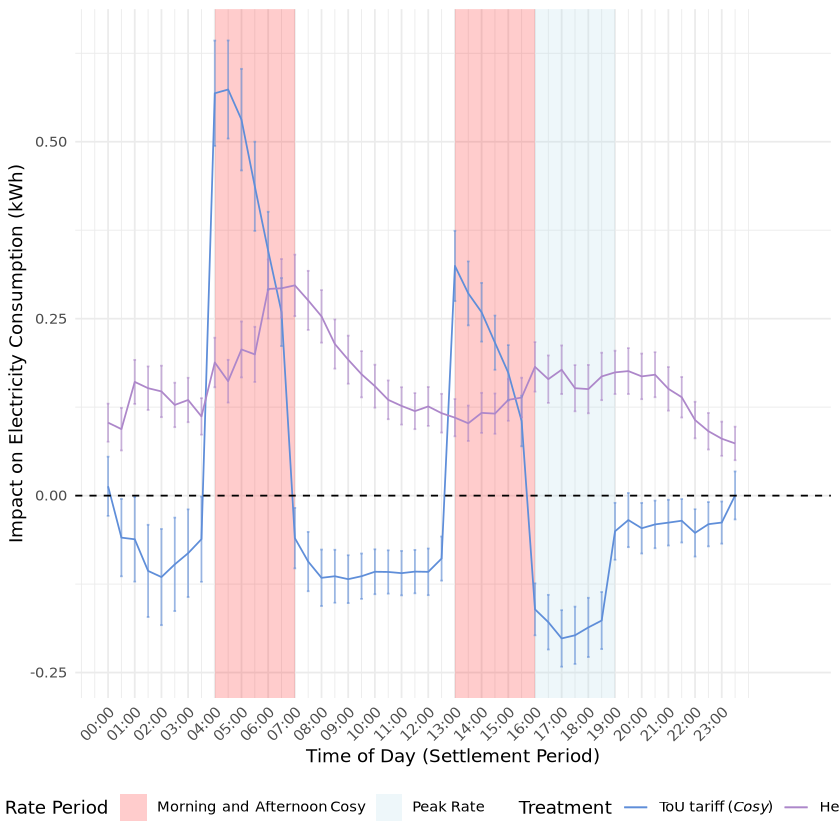

In [62]:
#install.packages("ggtext")
# Ensure ggtext is loaded for markdown functionality
library(ggtext)

# Apply the function to create time label
# Select a few representative time labels to display for clarity
selected_periods <- seq(min(coefs$settlement_period), max(coefs$settlement_period), by = 2)
display_labels <- coefs %>%
  filter(settlement_period %in% selected_periods) %>%
  distinct(settlement_period, time_label) %>%
  pull(time_label)


# Define the time periods for shading (settlement periods converted to numeric for xmin, xmax)
shaded_periods <- data.frame(
  xmin = c(9, 27, 33),  # 4-7 AM (periods 8-14), 1-4 PM (periods 26-32), 4-7 PM (periods 34-40)
  xmax = c(15, 33, 39),
  period_type = c("Morning and Afternoon Cosy", "Morning and Afternoon Cosy", "Peak Rate")
)

# Create the ggplot
ggplot(coefs, aes(x = settlement_period, y = Estimate, group = treatment, color = treatment)) +
  # Add shaded rectangles using the shaded_periods data
  geom_rect(data = shaded_periods, aes(xmin = xmin, xmax = xmax, ymin = -Inf, ymax = Inf, fill = period_type),
            inherit.aes = FALSE, alpha = 0.2) +   # Add transparency and disable inherited aesthetics
  geom_line() +
  geom_errorbar(aes(ymin = lower_ci, ymax = upper_ci), width = 0.2, alpha = 0.6) +
  scale_color_manual(
    name = "Treatment", 
    labels = c("hp" = "Heat Pump", "cosy" = "ToU tariff (*Cosy*)"),  # Italicizing Cosy using markdown
    values = c("hp" = hp_color, "cosy" = cosy_color)
  ) +
  scale_fill_manual(
    name = "Rate Period",  # Correct the fill legend
    values = c("Morning and Afternoon Cosy" = "red", "Peak Rate" = "lightblue"),  # Assign the correct colors
    labels = c("Morning and Afternoon Cosy" = "Morning and Afternoon Cosy", "Peak Rate" = "Peak Rate")
  ) +
  labs(
    x = "Time of Day (Settlement Period)",
    y = "Impact on Electricity Consumption (kWh)",
    color = "Treatment",
    fill = "Rate Period"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom",
    legend.text = element_markdown()  # Enable markdown-style formatting for the legend
  ) +
  scale_x_continuous(
    breaks = selected_periods,  # Ensure you define 'selected_periods' correctly
    labels = display_labels,    # Ensure 'display_labels' are defined or generated from 'settlement_period'
    expand = expansion(mult = c(0.05, 0.15))
  ) + 
  geom_hline(yintercept = 0, linetype = "dashed", color = "black")   # Add horizontal line at y = 0




In [63]:
# Save the plot if necessary
ggsave("../graphs/combined_impact_hourly_consumption.png", width = 10, height = 6, dpi = 300)
